In [ ]:
from utils.optimize_parameters import optimize_with_ax
import time
t1 = time.perf_counter()
# optimize_with_ax(samples_training=25, samples_test=25)
optimize_with_ax(samples_training=5, samples_test=5)

print(f"It took {round(time.perf_counter()-t1)} seconds to run basic run")
#model, X_train, X_test, y_train, y_test = main.differential_entropy_classification()

In [4]:
import nuscenes as ns

# Init Nusc object
data_folder = 'data/nuscenes/'
version = 'v1.0-trainval'
nusc = ns.nuscenes.NuScenes(version=version, dataroot=data_folder, verbose=False)

In [ ]:
# Load data
from utils.data_handling import read_nuscenes_data, split_data
PC_scenes = read_nuscenes_data(nusc, n_scenes=100, n_samples=100, downsample_factor=2,
                               T_close_thresh=1.5)
PC_scenes_training, PC_scenes_test = split_data(PC_scenes, scenes_training=60)
del PC_scenes

In [ ]:
from classifiers.differential_entropy import differential_entropy_dataset
from classifiers.regression import perform_logistic_regression

scale_factor = 5
params_diff_entropy = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}


X_train, y_train = differential_entropy_dataset(PC_scenes_training, params_diff_entropy)
X_test, y_test = differential_entropy_dataset(PC_scenes_test, params_diff_entropy)
model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=True)
print(f"Accuracy: {accuracy_test} with parameters\n {params_diff_entropy}")
print("Finito!")

In [17]:
from utils.data_handling import run_differential_entropy_on_dataset
from utils.parameters import Params
from classifiers.regression import perform_logistic_regression
import numpy as np

###### Define data to collect
n_scenes = 200
n_samples_per_scene = 1
train_ratio = 0.60 # Percent of data set aside for training, rest is for testing

####### Set parameters
scale_factor = 5
params_diff_entropy = {
    "rmin": 0.2*scale_factor,
    "rmax": 1*scale_factor,
    "log_epsilon": -18.0,
    "alpha": 1.33*scale_factor,
    "E_reject": 0.20
}
T_close_thresh = 1.5
downsample_factor = 1
verbose = False
hpr_radius_list = np.arange(2.75, 4, 0.5)
X_train_rads = []
y_train_rads = []
X_test_rads = []
y_test_rads = []
acc_rads = []
##
for hpr_radius in hpr_radius_list:
    print(f"Radius running: {hpr_radius}")
    params = Params(nusc=nusc, n_scenes=n_scenes, n_samples_per_scene=n_samples_per_scene, train_ratio=train_ratio,
                    downsample_factor=downsample_factor, T_close_thresh=T_close_thresh,
                    params_diff_entropy=params_diff_entropy, hpr_radius=hpr_radius)

    X_train, y_train, X_test, y_test = run_differential_entropy_on_dataset(params)
    X_train_rads.append(X_train)
    y_train_rads.append(y_train)
    X_test_rads.append(X_test)
    y_test_rads.append(y_test)

    #### Test performance
    model, accuracy_test = perform_logistic_regression(X_train, X_test, y_train, y_test, verbose=params.verbose)
    acc_rads.append(accuracy_test)
    print(f"Accuracy: {accuracy_test} with parameters\n {params_diff_entropy}")
    print("Finito!")


Radius running: 2.75
We have collected 50 number of samples
Total number of samples: 80
Total number of scenes:  80
Total number of samples: 40
Total number of scenes:  40
We have collected 50 number of samples
Total number of samples: 80
Total number of scenes:  80
Accuracy: 93.75 with parameters
 {'rmin': 1.0, 'rmax': 5, 'log_epsilon': -18.0, 'alpha': 6.65, 'E_reject': 0.2}
Finito!
Radius running: 3.25
We have collected 50 number of samples
Total number of samples: 80
Total number of scenes:  80
Total number of samples: 40
Total number of scenes:  40
We have collected 50 number of samples
Total number of samples: 80
Total number of scenes:  80
Accuracy: 96.25 with parameters
 {'rmin': 1.0, 'rmax': 5, 'log_epsilon': -18.0, 'alpha': 6.65, 'E_reject': 0.2}
Finito!
Radius running: 3.75
We have collected 50 number of samples
Total number of samples: 80
Total number of scenes:  80
Total number of samples: 40
Total number of scenes:  40
We have collected 50 number of samples
Total number of

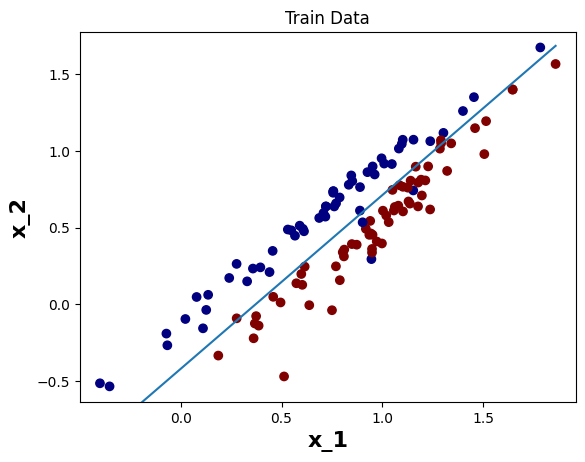

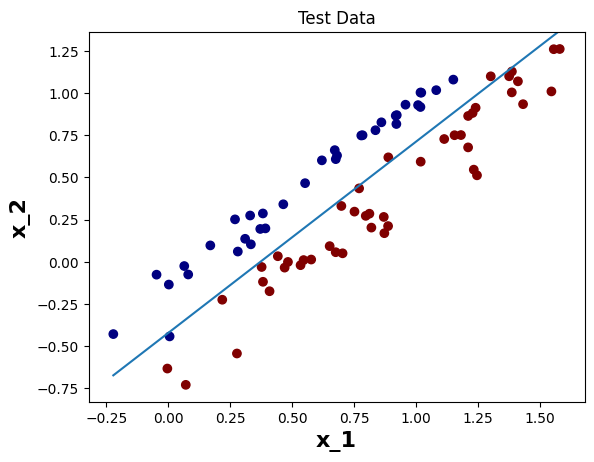

In [18]:
from visualization.classifications import model_plot

# Train Data
model_plot(model,X_train,y_train,'Train Data')
# Test Dataset Result9s
model_plot(model,X_test,y_test,'Test Data')

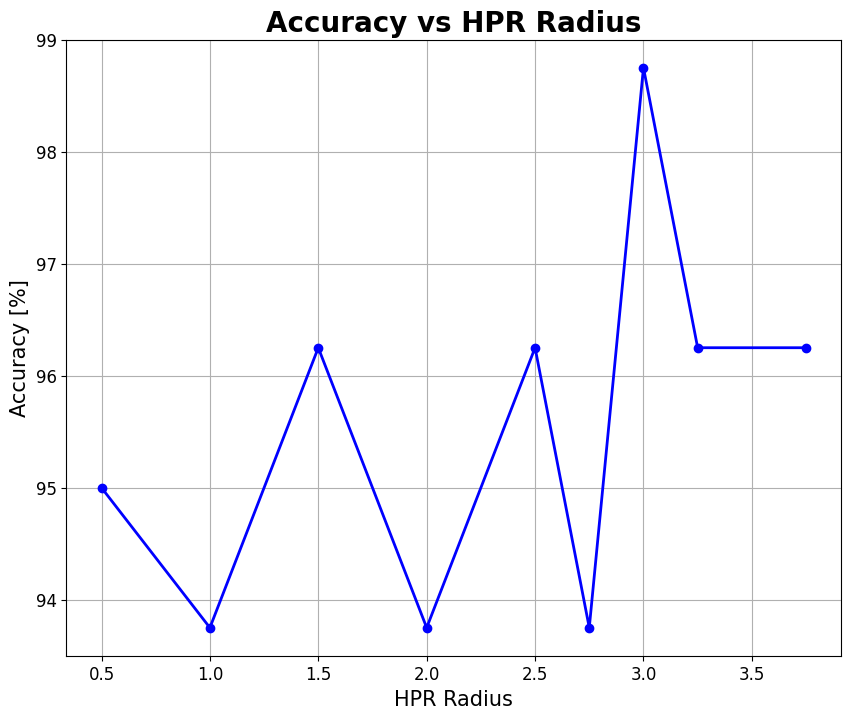

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_function(hpr_radius_list, acc_rads):
    plt.figure(figsize=(10,8)) # Bigger figure size
    plt.plot(hpr_radius_list, acc_rads, marker='o', linestyle='-', color='b', linewidth=2)
    plt.title('Accuracy vs HPR Radius', fontsize=20, fontweight='bold')
    plt.xlabel('HPR Radius', fontsize=15)
    plt.ylabel('Accuracy [%]', fontsize=15)
    plt.grid(True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.savefig('images/classification/CorAl_plus_covisibility/accuracy_vs_hpr_radius.eps', format='eps')
    plt.show()

# Call the function with your accuracy data
# Replace acc_radsd with your actual accuracy data
hpr_radius_list = [0.5, 1.000, 1.500, 2.000, 2.500, 2.750, 3.000, 3.250, 3.750]
acc_rads =        [ 95,  93.75, 96.25, 93.75, 96.25, 93.75, 98.75, 96.25, 96.25]

plot_function(hpr_radius_list, acc_rads)



In [ ]:
X_train_features = np.array(X_train_rads)
y_train_features = np.array(y_train_rads)
X_test_features = np.array(X_test_rads).reshape(())
y_test_features = np.array(y_test_rads).reshape((40, 16))
